[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb04_cross_family.ipynb)

In [1]:
# Colab setup: fetch the repo (data, results and the replayable LLM cache), work from its notebooks/ folder.
# Runs only on Colab; locally this cell does nothing. No API keys or paid calls are needed.
import os, subprocess, sys
if 'google.colab' in sys.modules and not os.path.exists('../src/lra'):
    repo = '/content/llm-regime-allocator'
    if not os.path.exists(repo):
        subprocess.run(['git', 'clone', '-q', '--depth', '1',
                        'https://github.com/FranQuant/llm-regime-allocator.git', repo], check=True)
    os.chdir(f'{repo}/notebooks')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pydantic>=2', 'scikit-learn'], check=True)

# nb04 — Does the result replicate across model families?

Phase 8 of `llm-regime-allocator`. nb02 found that Claude Sonnet 5.5, reading a **blinded** snapshot (every figure a z-score vs its own last 36 months, no levels, no date), forecasts the next-quarter regime better than uniform and than ML on the same inputs. Is that a property of LLMs, or of one model?

Three more families, each at the provider's default reasoning setting, same prompts, same 222 months:

| Model | Provider | Knowledge cutoff (provider docs) |
|---|---|---|
| Claude Sonnet 5.5 (reference, from nb02) | Anthropic | Jun 2026 |
| GPT-6.1-sol | OpenAI | Apr 2026 |
| Gemini 3.8 Flash | Google | Mar 2026 |
| GLM-5.3 (open weights, via Ollama Cloud) | Zhipu | not published |

**Pre-registered** in `configs/phase8.toml`, committed before the first paid call. A model *replicates* if, on 217 labelled months, its Brier score is below uniform (0.750), the block-bootstrap 95% CI of the gap excludes zero, **and** it beats the best walk-forward ML model on the blinded inputs (0.871). Everything below is read from `python scripts/score_phase8.py`; **no API calls**.

In [2]:
import sys
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
P8, L = Path('../results/phase8'), Path('../results/llm')
C = {'claude_sonnet': '#2a78d6', 'gpt_sol': '#eb6834', 'gemini_flash': '#1baf7a', 'glm': '#eda100'}
NAME = {'claude_sonnet': 'Sonnet 5.5', 'gpt_sol': 'GPT-6.1-sol', 'gemini_flash': 'Gemini 3.8 Flash',
        'glm': 'GLM-5.3', 'ensemble_4': 'average of 4', 'ensemble_3_new': 'average of 3 new'}
INK, MUTED = '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2,
                     'axes.edgecolor': MUTED, 'text.color': INK})
rd = lambda f: pd.read_csv(P8 / f)

## 1. The pre-registered test

In [3]:
pr = rd('primary.csv').set_index('model').rename(index=NAME)
pr[['brier', 'minus_uniform', 'ci_lo', 'ci_hi', 'hit_rate', 'brier_first_release', 'replicates']].round(3)

,brier,minus_uniform,ci_lo,ci_hi,hit_rate,brier_first_release,replicates
model,,,,,,,
Sonnet 5.5,0.668,-0.082,-0.140,-0.028,0.456,0.646,True
GPT-6.1-sol,0.689,-0.061,-0.122,-0.001,0.396,0.665,True
Gemini 3.8 Flash,0.724,-0.026,-0.101,0.052,0.456,0.687,False
GLM-5.3,0.719,-0.031,-0.089,0.026,0.387,0.688,False
average of 4,0.688,-0.062,-0.124,-0.001,0.429,0.659,True
average of 3 new,0.700,-0.050,-0.114,0.014,0.415,0.669,False


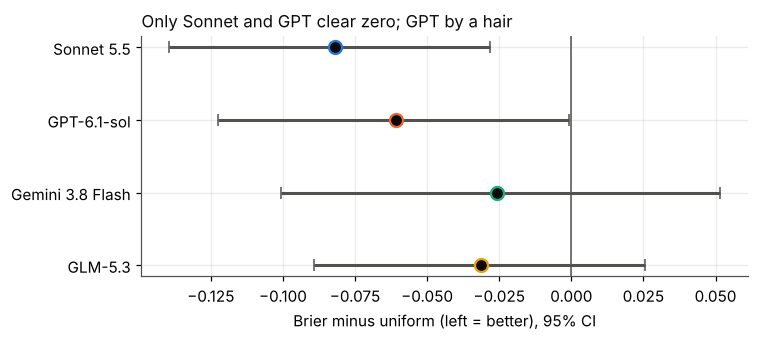

In [4]:
m = pr.loc[[NAME[k] for k in C]]
fig, ax = plt.subplots(figsize=(7, 3.2))
y = np.arange(len(m))[::-1]
ax.errorbar(m.minus_uniform, y, xerr=[m.minus_uniform - m.ci_lo, m.ci_hi - m.minus_uniform], fmt='o',
            color=INK, ecolor=MUTED, capsize=4)
for yi, k in zip(y, C):
    ax.plot(m.loc[NAME[k], 'minus_uniform'], yi, 'o', color=C[k], ms=9)
ax.axvline(0, color=MUTED, lw=1)
ax.set_yticks(y, m.index); ax.set_xlabel('Brier minus uniform (left = better), 95% CI')
ax.set_title('Only Sonnet and GPT clear zero; GPT by a hair', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**Reading.** All four LLMs have a lower Brier than uniform and all four beat ML on identical inputs (0.67–0.72 vs 0.87): that part replicates across families. Clearing *uniform* with confidence does not: Gemini and GLM have intervals that include zero. Labels from first data releases instead of today's vintage improve every model by about 0.02–0.04 and change no ranking.

## 2. Contamination: can each model date the blinded snapshot?

The date-recovery probe asks *which month is this?* on the same blinded snapshot. Blinding was designed on Sonnet (nb02). The question here is whether it holds for other models.

In [5]:
rd('probe.csv').set_index('model').rename(index=NAME)[['status', 'mae_months', 'exact_month', 'within_12m',
    'brier_gain_datable', 'brier_gain_undatable', 'n_datable', 'n_undatable']].round(3)

,status,mae_months,exact_month,within_12m,brier_gain_datable,brier_gain_undatable,n_datable,n_undatable
model,,,,,,,,
Sonnet 5.5,complete,45.550,0.135,0.496,-0.114,-0.051,108.0,109.0
GPT-6.1-sol,complete,2.000,0.941,0.982,-0.060,-0.316,216.0,1.0
Gemini 3.8 Flash,complete,37.022,0.293,0.604,-0.045,0.004,134.0,83.0
GLM-5.3,not completed (reasoning exceeded the output cap),NaN,NaN,NaN,NaN,NaN,NaN,NaN


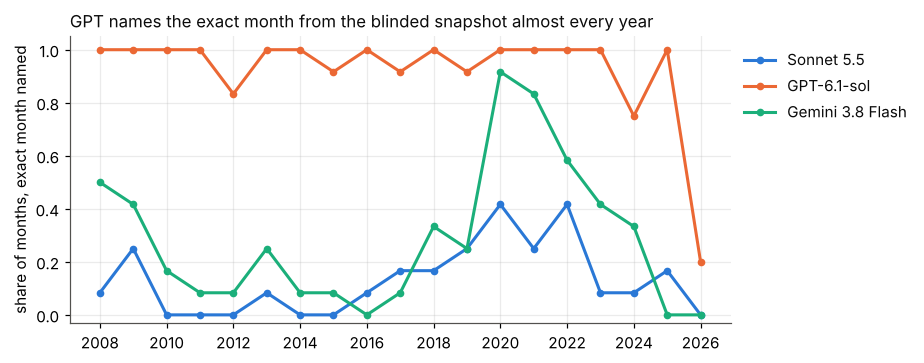

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
for k in ('claude_sonnet', 'gpt_sol', 'gemini_flash'):
    e = pd.read_csv(L / k / 'date_probe_blinded_run0.csv', parse_dates=['date'], index_col='date')['error_months']
    e = e.loc['2008':]                       # 2007 has a single month
    s = (e.abs() == 0).groupby(e.index.year).mean()
    ax.plot(s.index, s.values, marker='o', ms=4, color=C[k], label=NAME[k])
ax.set_xticks(range(2008, 2027, 2))
ax.set_ylabel('share of months, exact month named'); ax.set_ylim(-0.03, 1.05)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.0, 1.0))
ax.set_title('GPT names the exact month from the blinded snapshot almost every year', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

In [7]:
g = pd.read_csv(L / 'gpt_sol' / 'date_probe_blinded_run0.csv', parse_dates=['date'], index_col='date')
g.loc['2025-10':, ['guess_year', 'guess_month', 'error_months', 'confidence']]   # GPT near its Apr-2026 cutoff

,guess_year,guess_month,error_months,confidence
date,,,,
2025-10-31,2025.0,10.0,0.0,0.88
2025-11-28,2025.0,11.0,0.0,0.96
2025-12-31,2025.0,12.0,0.0,0.94
2026-01-30,2026.0,1.0,0.0,0.88
2026-02-27,2026.0,3.0,1.0,0.50
2026-03-31,2013.0,6.0,-153.0,0.35
2026-04-30,2020.0,11.0,-65.0,0.55
2026-05-29,2021.0,4.0,-61.0,0.76


**Reading.** Blinding is not model-proof. GPT-6.1-sol names the **exact month in 94%** of cases from z-scores alone (Sonnet 14%, Gemini 29%), citing episodes such as gold's 2013 collapse or Operation Twist. It is exact through January 2026 and then breaks down from March 2026, in the last weeks before its April 2026 knowledge cutoff and after it, where its training data thins out — the signature of memory, not of a general dating skill. Consequence: GPT passes the pre-registered test, but its pass cannot count as clean evidence, because it can tell which month it is looking at in 216 of 217 scored months. GLM's probe did not complete (below), so its contamination is unmeasured.

## 3. Stability: a second run on every 4th month

None of these models can be made deterministic (reasoning models, provider defaults), so run-to-run variance is measured instead.

In [8]:
rd('variance.csv').set_index('model').rename(index=NAME).round(3)

,n_months,n_scored,brier_run0,brier_run1,mean_abs_dp,same_top_regime
model,,,,,,
GPT-6.1-sol,56,54,0.681,0.663,0.020,0.946
Gemini 3.8 Flash,56,54,0.732,0.721,0.024,0.964
GLM-5.3,56,54,0.718,0.729,0.049,0.857


**Reading.** Answers are stable: probabilities move by 2–5 points on average and the top regime is the same 86–96% of the time. Single-run results are not noise-dominated.

## 4. Do the models agree?

In [9]:
a = rd('agreement.csv'); a['pair'] = a.a.map(NAME) + ' – ' + a.b.map(NAME)
a.set_index('pair')[['mean_tv_distance', 'same_top_regime']].round(3)

,mean_tv_distance,same_top_regime
pair,,
Sonnet 5.5 – GPT-6.1-sol,0.121,0.743
Sonnet 5.5 – Gemini 3.8 Flash,0.172,0.806
Sonnet 5.5 – GLM-5.3,0.119,0.757
GPT-6.1-sol – Gemini 3.8 Flash,0.119,0.865
GPT-6.1-sol – GLM-5.3,0.129,0.716
Gemini 3.8 Flash – GLM-5.3,0.162,0.761


**Reading.** Different families make similar calls: the same top regime in 72–87% of months, mean total-variation distance 0.12–0.17. The equal-weight average of the four (Section 1) scores 0.688 — no better than Sonnet alone, so the errors are largely shared.

## 5. Portfolios (descriptive, not part of the test)

Same playbook and post-hoc BL machinery as nb03; Sharpe and drawdown net of 2.5 bps; the difference vs the uniform-probability control with a 6-month block-bootstrap CI on monthly excess returns.

In [10]:
pf = rd('portfolios.csv')
pf['strategy'] = pf.strategy.str.replace('llm_', '').str.replace('_blinded', '')
pf.set_index('strategy').round(3)

,sharpe,max_drawdown,sharpe_diff_vs_uniform_monthly,ci_lo,ci_hi
strategy,,,,,
playbook__sonnet,0.756,-0.157,0.142,-0.034,0.310
playbook__gpt_sol,0.710,-0.189,0.091,-0.063,0.233
playbook__gemini_flash,0.718,-0.188,0.105,-0.069,0.259
playbook__glm,0.731,-0.192,0.113,-0.015,0.227
playbook__ensemble_4,0.733,-0.181,0.116,-0.039,0.258
playbook__ml_gbt,0.587,-0.269,-0.004,-0.160,0.118
playbook__ml_gbt,0.752,-0.183,0.139,-0.084,0.299
playbook__oracle,0.961,-0.143,0.352,0.010,0.661
bl_playbook__sonnet,0.649,-0.240,0.056,-0.026,0.135


**Reading.** Every LLM playbook lands at Sharpe 0.71–0.76 with drawdowns of −16% to −19% (uniform control 0.61; 60/40 0.66, −32%). None is statistically distinguishable from the control; only the look-ahead oracle is.

## 6. Deviations and limits (all declared in `configs/phase8.toml`)

* **Provider errors** are retried with backoff and never scored; no fallback model was used.
* **GLM probe not completed.** GLM-5.3 kept reasoning past the 8,000-token cap on every probe call (the pilot covered the regime task only). A declared re-run at 32,000 tokens also truncated, so per the pre-registered rule its probe is reported as not completed. The 220 truncated answers are committed in `results/llm_cache_truncated/`. GLM's regime calls are complete (one parse retry, no failed month).
* **One reasoning setting per model** (provider default) and one main run; variance measured on 56 months.
* **Cutoffs.** Every model's cutoff is after 2026-03, so there is no clean backtest window for any of them.

## What we can and cannot claim

* **Replicates across families:** LLMs read the blinded macro snapshot better than standard ML given identical inputs — all four, by a wide margin (Brier 0.67–0.72 vs 0.87).
* **Does not replicate cleanly:** beating *uniform* with statistical confidence. Sonnet does; GPT does but is contaminated; Gemini and GLM do not.
* **New finding:** removing levels does not hide history from a strong reasoner. GPT dates relative signals almost perfectly before its cutoff and not after. Any backtest of an LLM forecaster on pre-cutoff data should report a date-recovery probe per model.
* **Open:** whether the edge over uniform is reading or remembering. No backtest can settle it for frontier models. Next: **Phase 9**, a counterfactual test (edit the snapshot; does the call follow the data or the memory?), and **Phase 10**, all four models in the live, pre-committed monthly log.